<a href="https://colab.research.google.com/github/yashsati072-create/Movie-Recommendation-System/blob/main/Another_copy_of_Movie_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import os
import zipfile
os.environ['KAGGLE_API_TOKEN'] = ''
!pip install -q kaggle
!kaggle datasets download -d rounakbanik/the-movies-dataset

Dataset URL: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
License(s): CC0-1.0
100% 228M/228M [00:14<00:00, 16.3MB/s]



In [2]:
with zipfile.ZipFile('the-movies-dataset.zip','r') as zip_ref:
  zip_ref.extractall('dataset')

base = "dataset"
credit = pd.read_csv(f"{base}/credits.csv")
keyword=pd.read_csv(f"{base}/keywords.csv")
link=pd.read_csv(f"{base}/links.csv")
link_small=pd.read_csv(f"{base}/links_small.csv")
movie_da=pd.read_csv(f"{base}/movies_metadata.csv")
rating=pd.read_csv(f"{base}/ratings.csv")
rating_sm=pd.read_csv(f"{base}/ratings_small.csv")

/tmp/ipykernel_1139/3571181893.py:9: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movie_da=pd.read_csv(f"{base}/movies_metadata.csv")


# Data Inspection


In [3]:
credit.head(10)
print(f"Shape:{credit.shape}")
print(f"Columns:{list(credit.columns)}")
print('\n Missing Values:')
print(credit.isnull().sum())
print(f"Duplicate:{credit.duplicated().sum()}")



Shape:(45476, 3)
Columns:['cast', 'crew', 'id']

 Missing Values:
cast    0
crew    0
id      0
dtype: int64
Duplicate:37


In [4]:
credit=credit.drop_duplicates()

#Keyword Data Inespection

In [5]:
keyword.head(10)
print(f"Shape:{keyword.shape}")
print(f"Columns:{list(keyword.columns)}")
print('\n Missing Values:')
print(keyword.isnull().sum())
print(f"Duplicate:{keyword.duplicated().sum()}")
keyword=keyword.drop_duplicates()



Shape:(46419, 2)
Columns:['id', 'keywords']

 Missing Values:
id          0
keywords    0
dtype: int64
Duplicate:987


#Links Data inspection

In [6]:
print(f"Head of top 5",link.head(5))
print(f"Shape:{link.shape}"
)
print(f"Columns:{list(link.columns)}")
print('\n Missing Values:')
print(link.isnull().sum())
print(f"Duplicate:{link.duplicated().sum()})")

Head of top 5    movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0
Shape:(45843, 3)
Columns:['movieId', 'imdbId', 'tmdbId']

 Missing Values:
movieId      0
imdbId       0
tmdbId     219
dtype: int64
Duplicate:0)


In [7]:
link['tmdbId'].fillna(link["tmdbId"].median(),inplace=True)

/tmp/ipykernel_1139/1024811610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  link['tmdbId'].fillna(link["tmdbId"].median(),inplace=True)


#Links small Data inspection


In [8]:
link_small.head(10)

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0
5,6,113277,949.0
6,7,114319,11860.0
7,8,112302,45325.0
8,9,114576,9091.0
9,10,113189,710.0


In [9]:
link_small.head(10)
print(f"Shape:{link_small.shape}"
)
print(f"Columns:{list(link_small.columns)}")
print('\n Missing Values:')
print(link_small.isnull().sum())
print(f"Duplicate:{link_small.duplicated().sum()})")

Shape:(9125, 3)
Columns:['movieId', 'imdbId', 'tmdbId']

 Missing Values:
movieId     0
imdbId      0
tmdbId     13
dtype: int64
Duplicate:0)


In [10]:

link_small['tmdbId'].fillna(link_small["tmdbId"].median(),inplace=True)

/tmp/ipykernel_1139/679080834.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  link_small['tmdbId'].fillna(link_small["tmdbId"].median(),inplace=True)


# movie metadata data inspection


In [11]:
movie_da.head(10)
print(f"Shape:{movie_da.shape}"
)
print(f"Columns:{list(movie_da.columns)}")
print('\n Missing Values:')
print(movie_da.isnull().sum())
print(f"Duplicate:{movie_da.duplicated().sum()})")

Shape:(45466, 24)
Columns:['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

 Missing Values:
adult                        0
belongs_to_collection    40972
budget                       0
genres                       0
homepage                 37684
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  250

In [12]:
movie_da.tail()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
45461,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45462,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45463,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45464,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0
45465,False,NaN,0,[],NaN,461257,tt6980792,en,Queerama,50 years after decriminalisation of homosexual...,...,2017-06-09,0.0,75.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Queerama,False,0.0,0.0


In [13]:
# # Remove extra spaces
# movie_da['belongs_to_collection'] = movie_da['belongs_to_collection'].astype(str).str.strip()


In [14]:
# movie_da=movie_da.drop_duplicates()
# movie_da['belongs_to_collection'] = movie_da['belongs_to_collection'].fillna('No Collection')
# movie_da['homepage'] = movie_da['homepage'].fillna('No URL')
# movie_da['imdb_id']=movie_da['imdb_id'].fillna('no imdb_id')
# movie_da['original_language'] = movie_da['original_language'].fillna('en')



# movie_da.head()

In [15]:
print(f"Shape:{rating.shape}")
print(f"Columns:{list(rating.columns)}")
print("\n Missing Values:")
print(rating.isnull().sum())
print(f"Duplicate:{rating.duplicated().sum()})")

Shape:(26024289, 4)
Columns:['userId', 'movieId', 'rating', 'timestamp']

 Missing Values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate:0)


In [16]:
print(f"Shape:{rating_sm}")
print(f"Columns:{list(rating_sm)}")
print("\n Missing Values:")
print(rating_sm.isnull().sum())
print(f"Duplicate:{rating_sm.duplicated()})")

Shape:        userId  movieId  rating   timestamp
0            1       31     2.5  1260759144
1            1     1029     3.0  1260759179
2            1     1061     3.0  1260759182
3            1     1129     2.0  1260759185
4            1     1172     4.0  1260759205
...        ...      ...     ...         ...
99999      671     6268     2.5  1065579370
100000     671     6269     4.0  1065149201
100001     671     6365     4.0  1070940363
100002     671     6385     2.5  1070979663
100003     671     6565     3.5  1074784724

[100004 rows x 4 columns]
Columns:['userId', 'movieId', 'rating', 'timestamp']

 Missing Values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate:0         False
1         False
2         False
3         False
4         False
          ...  
99999     False
100000    False
100001    False
100002    False
100003    False
Length: 100004, dtype: bool)


In [17]:
movie_da['overview']=movie_da['overview'].fillna('Not available')
movie_da['overview'].isna().sum()
movie_da.tail()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
45461,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45462,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45463,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45464,False,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0
45465,False,NaN,0,[],NaN,461257,tt6980792,en,Queerama,50 years after decriminalisation of homosexual...,...,2017-06-09,0.0,75.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Queerama,False,0.0,0.0


In [18]:
movie_da['popularity'].dtype

dtype('O')

In [19]:
movie_da['popularity']=pd.to_numeric(movie_da['popularity'],errors='coerce')


In [20]:
movie_da['popularity'].fillna(
    movie_da['popularity'].median(),
    inplace=True
)

/tmp/ipykernel_1139/3154952449.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_da['popularity'].fillna(


In [21]:

movie_da['poster_path']=movie_da['poster_path'].fillna('Not available')


In [22]:

movie_da['production_companies']=movie_da['production_companies'].fillna('Not available')


In [23]:
movie_da['production_countries'].head()
movie_da['production_countries']=movie_da['production_countries'].fillna('Not available')

In [24]:
movie_da['release_date'].head()
movie_da=movie_da.dropna(subset=['release_date'])

In [25]:
# movie_da['revenue'].head()
# movie_da['revenue']=movie_da['revenue'].fillna(movie_da['revenue'].median())

In [26]:
movie_da['runtime'].head()

print('\n Missing Values:')
print(movie_da.isnull().sum())


 Missing Values:
adult                        0
belongs_to_collection    40888
budget                       0
genres                       0
homepage                 37610
id                           0
imdb_id                     14
original_language           11
original_title               0
overview                     0
popularity                   0
poster_path                  0
production_companies         0
production_countries         0
release_date                 0
revenue                      3
runtime                    249
spoken_languages             3
status                      83
tagline                  24981
title                        3
video                        3
vote_average                 3
vote_count                   3
dtype: int64


In [27]:
movie_da['runtime']=movie_da['runtime'].fillna(movie_da['runtime'].median())

In [28]:
movie_da['spoken_languages']=movie_da['spoken_languages'].fillna('Not available')

In [29]:
movie_da['status']=movie_da['status'].fillna(movie_da['status'].mode()[0])

In [30]:
movie_da=movie_da.dropna(subset=['title'])




In [31]:
movie_da['video'].head()
movie_da['video']=movie_da['video'].fillna(movie_da['video'].mode()[0])

/tmp/ipykernel_1139/1864039786.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  movie_da['video']=movie_da['video'].fillna(movie_da['video'].mode()[0])


In [32]:
movie_da['vote_average'].head()
movie_da['vote_count'].head()
movie_da['vote_average']=movie_da['vote_average'].fillna(movie_da['vote_average'].median())
movie_da['vote_count']=movie_da['vote_count'].fillna(movie_da['vote_count'].median())

In [33]:
movie_da.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [34]:
pd.set_option('display.max_columns', None)

print(movie_da.head())

   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   
2  False  {'id': 119050, 'name': 'Grumpy Old Men Collect...         0   
3  False                                                NaN  16000000   
4  False  {'id': 96871, 'name': 'Father of the Bride Col...         0   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...   
4                     [{'id': 35, 'name': 'Comedy'}]   

                               homepage     id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story    862  tt0114709                en   
1                                   NaN   8844  tt0113497         

In [35]:
movie_da.head(50)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
5,False,NaN,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",17.924927,/zMyfPUelumio3tiDKPffaUpsQTD.jpg,"[{'name': 'Regency Enterprises', 'id': 508}, {...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0
6,False,NaN,58000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,11860,tt0114319,en,Sabrina,An ugly duckling having undergone a remarkable...,6.677277,/jQh15y5YB7bWz1NtffNZmRw0s9D.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'DE', 'name': 'Germany'}, {'is...",1995-12-15,0.0,127.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,You are cordially invited to the most surprisi...,Sabrina,False,6.2,141.0
7,False,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,45325,tt0112302,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",2.561161,/sGO5Qa55p7wTu7FJcX4H4xIVKvS.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,97.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Original Bad Boys.,

In [36]:
movie_da.drop('belongs_to_collection',axis=1,inplace=True)

In [37]:
movie_da.isnull().sum()

,0
adult,0
budget,0
genres,0
homepage,37610
id,0
imdb_id,14
original_language,11
original_title,0
overview,0
popularity,0


In [38]:
movie_da.shape[0]

45376

In [39]:
movie_da.head()

,adult,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [40]:
movie_da.drop_duplicates(inplace=True)

In [41]:
movie_da.dtypes

,0
adult,object
budget,object
genres,object
homepage,object
id,object
imdb_id,object
original_language,object
original_title,object
overview,object
popularity,float64


In [42]:
movie_da['budget']=pd.to_numeric(movie_da['budget'],errors='coerce')
movie_da['id']=pd.to_numeric(movie_da['id'],errors='coerce')
movie_da['release_date']=pd.to_numeric(movie_da['release_date'],errors='coerce')


In [43]:
movie_da['adult'].value_counts()

,count
adult,
False,45351
True,8


In [44]:
movie_da.head()

,adult,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",NaN,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",NaN,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",NaN,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",NaN,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",NaN,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [45]:
movie_da.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45359 entries, 0 to 45465
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   adult                 45359 non-null  object 
 1   budget                45359 non-null  int64  
 2   genres                45359 non-null  object 
 3   homepage              7764 non-null   object 
 4   id                    45359 non-null  int64  
 5   imdb_id               45345 non-null  object 
 6   original_language     45348 non-null  object 
 7   original_title        45359 non-null  object 
 8   overview              45359 non-null  object 
 9   popularity            45359 non-null  float64
 10  poster_path           45359 non-null  object 
 11  production_companies  45359 non-null  object 
 12  production_countries  45359 non-null  object 
 13  release_date          0 non-null      float64
 14  revenue               45359 non-null  float64
 15  runtime               45

In [46]:
movie_da.isnull().sum()

,0
adult,0
budget,0
genres,0
homepage,37595
id,0
imdb_id,14
original_language,11
original_title,0
overview,0
popularity,0


In [47]:
movie_da.describe()

,budget,id,popularity,release_date,revenue,runtime,vote_average,vote_count
count,4.535900e+04,45359.000000,45359.000000,0.0,4.535900e+04,45359.000000,45359.000000,45359.000000
mean,4.234169e+06,108026.198836,2.926491,NaN,1.123427e+07,94.184175,5.624176,110.121431
std,1.744294e+07,112177.776233,6.010366,NaN,6.440166e+07,38.241627,1.915294,491.831125
min,0.000000e+00,2.000000,0.000000,NaN,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,26386.500000,0.388855,NaN,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,59852.000000,1.130406,NaN,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,156538.000000,3.691946,NaN,0.000000e+00,107.000000,6.800000,34.000000
max,3.800000e+08,469172.000000,547.488298,NaN,2.787965e+09,1256.000000,10.000000,14075.000000


In [48]:
movie_da['release_date'].unique()[:10]

array([nan])

In [49]:
movie_da['release_date'].head()

,release_date
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [50]:
movie_da.drop('release_date',axis=1,inplace=True)



In [51]:
movie_da.drop('tagline',axis=1,inplace=True)


In [52]:
movie_da.drop('homepage',axis=1,inplace=True)

In [53]:
movie_da.isnull().sum()

,0
adult,0
budget,0
genres,0
id,0
imdb_id,14
original_language,11
original_title,0
overview,0
popularity,0
poster_path,0


In [54]:
movie_da.dropna(subset=['imdb_id'],inplace=True)

In [55]:
movie_da['original_language'].fillna('unknown',inplace=True)

/tmp/ipykernel_1139/2063061912.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_da['original_language'].fillna('unknown',inplace=True)


In [64]:
movie_da.head(10)

,adult,budget,genres,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,revenue,runtime,spoken_languages,status,title,video,vote_average,vote_count
0,False,30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Toy Story,False,7.7,5415.0
1,False,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Jumanji,False,6.9,2413.0
2,False,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Grumpier Old Men,False,6.5,92.0
3,False,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,[{'name': 'Twentieth Century Fox Film Corporat...,"[{'iso_3166_1': 'US', 'name': 'United States o...",81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Waiting to Exhale,False,6.1,34.0
4,False,0,"[{'id': 35, 'name': 'Comedy'}]",11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,"[{'name': 'Sandollar Productions', 'id': 5842}...","[{'iso_3166_1': 'US', 'name': 'United States o...",76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Father of the Bride Part II,False,5.7,173.0
5,False,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",17.924927,/zMyfPUelumio3tiDKPffaUpsQTD.jpg,"[{'name': 'Regency Enterprises', 'id': 508}, {...","[{'iso_3166_1': 'US', 'name': 'United States o...",187436818.0,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Heat,False,7.7,1886.0
6,False,58000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",11860,tt0114319,en,Sabrina,An ugly duckling having undergone a remarkable...,6.677277,/jQh15y5YB7bWz1NtffNZmRw0s9D.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'DE', 'name': 'Germany'}, {'is...",0.0,127.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,Sabrina,False,6.2,141.0
7,False,0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",45325,tt0112302,en,Tom and Huck,"A mischievous young boy, Tom Sawyer, witnesses...",2.561161,/sGO5Qa55p7wTu7FJcX4H4xIVKvS.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,97.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Tom and Huck,False,5.4,45.0
8,False,35000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",9091,tt0114576,en,Sudden Death,International action superstar Jean Claude Van...,5.231580,/eoWvKD60lT95Ss1MYNgVExpo5iU.jpg,"[{'name': 'Universal Pictures', 'id': 33}, {'n...","[{'iso_3166_1': 'US', 'name': 'United States o...",64350171.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Sudden Death,False,5.5,174.0
9,False,58000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",710,tt0113189,en,GoldenEye,James Bond must unmask the mysterious head of ...,14.686036,/5c0ovjT41KnYIHYuF4AWsTe3sKh.jpg,"[{'name': 'United Artists', 'id': 60}, {'name'...","[{'iso_3166

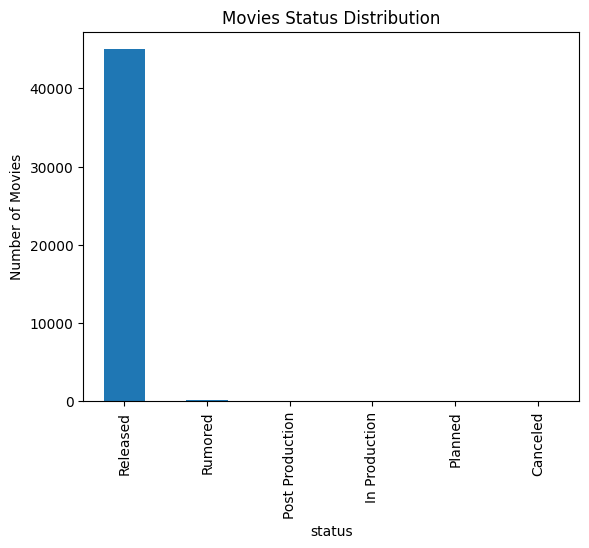

In [60]:
import matplotlib.pyplot as plt
movie_da['status'].value_counts().plot(kind='bar')
plt.title('Movies Status Distribution')
plt.xlabel('status')
plt.ylabel('Number of Movies')
plt.show()

In [63]:
movie_da['popularity'].describe()

,popularity
count,45345.000000
mean,2.927115
std,6.011137
min,0.000000
25%,0.389045
50%,1.131018
75%,3.693288
max,547.488298


In [67]:
movie_da.nlargest(10,'popularity')[['title','popularity']]

,title,popularity
30700,Minions,547.488298
33356,Wonder Woman,294.337037
42222,Beauty and the Beast,287.253654
43644,Baby Driver,228.032744
24455,Big Hero 6,213.849907
26564,Deadpool,187.860492
26566,Guardians of the Galaxy Vol. 2,185.330992
14551,Avatar,185.070892
24351,John Wick,183.870374
23675,Gone Girl,154.801009


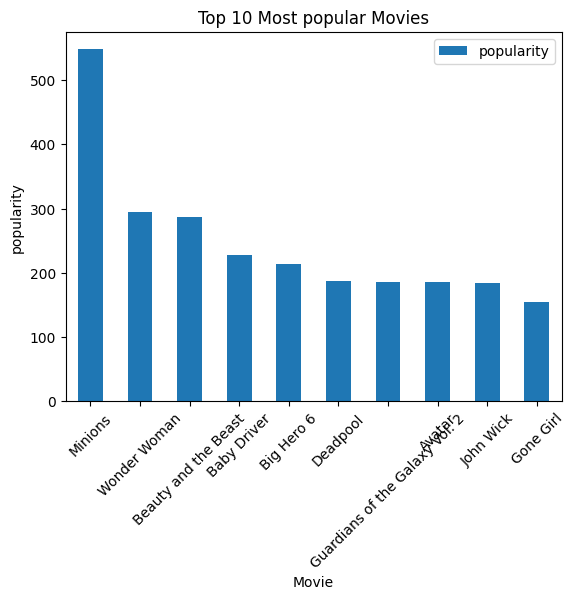

In [70]:
movie_da.nlargest(10,'popularity').plot(x='title',y='popularity',kind='bar')
plt.title('Top 10 Most popular Movies')
plt.xlabel('Movie')
plt.ylabel('popularity')
plt.xticks(rotation=45)
plt.show()


In [72]:
movie_da['vote_average'].describe()

,vote_average
count,45345.000000
mean,5.624616
std,1.914498
min,0.000000
25%,5.000000
50%,6.000000
75%,6.800000
max,10.000000


In [80]:
movie_da.nlargest(10,'vote_average')[['title','vote_average','vote_count']]


,title,vote_average,vote_count
186,Reckless,10.0,1.0
394,Girl in the Cadillac,10.0,1.0
706,"The Haunted World of Edward D. Wood, Jr.",10.0,1.0
738,Carmen Miranda: Bananas Is My Business,10.0,1.0
1634,Other Voices Other Rooms,10.0,1.0
1761,"Dancer, Texas Pop. 81",10.0,1.0
2114,The Farmer's Wife,10.0,1.0
2653,Stiff Upper Lips,10.0,1.0
2948,Ten Benny,10.0,1.0
3160,Gendernauts: A Journey Through Shifting Identi...,10.0,2.0


In [91]:
movie_da[
    (movie_da['vote_average'] >= 9) &
    (movie_da['vote_count'] >= 100)
][['title', 'vote_average', 'vote_count']].sort_values(
    'vote_average', ascending=False
).head(10)

,title,vote_average,vote_count
10309,Dilwale Dulhania Le Jayenge,9.1,661.0


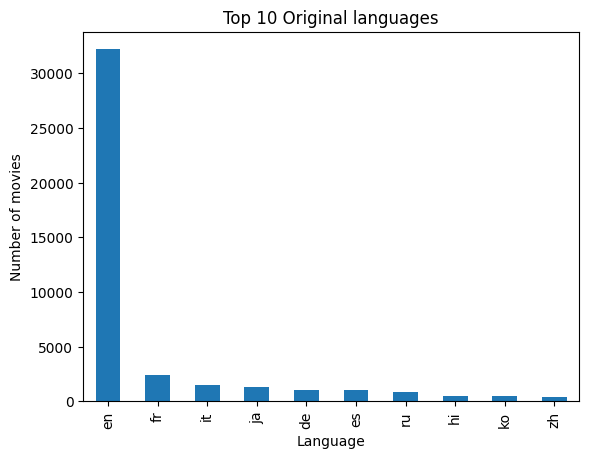

In [95]:
movie_da['original_language'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Original languages')
plt.xlabel('Language')
plt.ylabel('Number of movies')
plt.show()

In [96]:
movie_da.nlargest(10,'revenue')[['title','revenue']]

,title,revenue
14551,Avatar,2.787965e+09
26555,Star Wars: The Force Awakens,2.068224e+09
1639,Titanic,1.845034e+09
17818,The Avengers,1.519558e+09
25084,Jurassic World,1.513529e+09
28830,Furious 7,1.506249e+09
26558,Avengers: Age of Ultron,1.405404e+09
17437,Harry Potter and the Deathly Hallows: Part 2,1.342000e+09
22110,Frozen,1.274219e+09
42222,Beauty and the Beast,1.262886e+09
